In [14]:
from method.qnn import QuantumNeuralNetwork, CorrelatorQuantumNeuralNetwork
from circuits.generate import make_ansatz
from equation.option_pricing import BlackScholes
from optimize.option_princing import BlackScholeOptimizer
from method.hnn import HybridCQN

import matplotlib.pyplot as plt

In [15]:
bse = BlackScholes()
data_train = bse.generate_data()



In [16]:
ansatz_basic = make_ansatz("strong")
model = QuantumNeuralNetwork(n_qubits=7, n_layers=3, ansatz_fn=ansatz_basic, circuit_type="strong")
model = HybridCQN(classical_pre=None, qnn_block=model, classical_post=None)
opt = BlackScholeOptimizer(data=data_train, model=model, epochs=5000)
loss_strong = opt.train(return_loss=True, return_all=True)

Trainning: 100%|██████████| 5000/5000 [48:07<00:00,  1.73it/s]


In [17]:
ansatz_basic = make_ansatz("basic")
model = QuantumNeuralNetwork(n_qubits=7, n_layers=3, ansatz_fn=ansatz_basic, circuit_type="basic")
model = HybridCQN(classical_pre=None, qnn_block=model, classical_post=None)
opt = BlackScholeOptimizer(data=data_train, model=model, epochs=5000)
loss_basic = opt.train(return_loss=True, return_all=True)

Trainning: 100%|██████████| 5000/5000 [45:57<00:00,  1.81it/s]


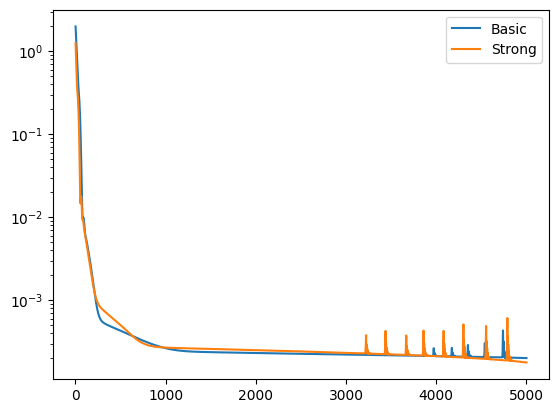

In [18]:
plt.plot(range(1,len(loss_basic["Total"])+1), loss_basic["Total"], label="Basic")
plt.plot(range(1,len(loss_basic["Total"])+1), loss_strong["Total"], label="Strong")

plt.yscale("log")

#plt.plot(range(1,len(loss["Total"])+1), loss["boundary_0_loss"], label="S=0")
#plt.plot(range(1,len(loss["Total"])+1), loss["boundary_max_loss"], label="S_max")
#plt.plot(range(1,len(loss["Total"])+1), loss["pde_loss"], label="PDE")
#plt.plot(range(1,len(loss["Total"])+1), loss["terminal_loss"], label="t=tau")

plt.legend()
plt.show()

In [19]:
ansatz_basic = make_ansatz("strong")
model = CorrelatorQuantumNeuralNetwork(n_qubits=4, n_vertex=7, n_layers=3, ansatz_fn=ansatz_basic, circuit_type="strong")
model = HybridCQN(classical_pre=None, qnn_block=model, classical_post=None)
opt = BlackScholeOptimizer(data=data_train, model=model, epochs=5000)
loss_cqnn= opt.train(return_loss=True, return_all=True)

Trainning: 100%|██████████| 5000/5000 [07:02<00:00, 11.83it/s]


In [20]:
ansatz_basic = make_ansatz("strong")
model = CorrelatorQuantumNeuralNetwork(n_qubits=4, n_vertex=7, n_layers=3, ansatz_fn=ansatz_basic, circuit_type="strong", nonlinear=True)
model = HybridCQN(classical_pre=None, qnn_block=model, classical_post=None)
opt = BlackScholeOptimizer(data=data_train, model=model, epochs=5000)
loss_cqnn_tanh= opt.train(return_loss=True, return_all=True)

Trainning: 100%|██████████| 5000/5000 [07:17<00:00, 11.44it/s]


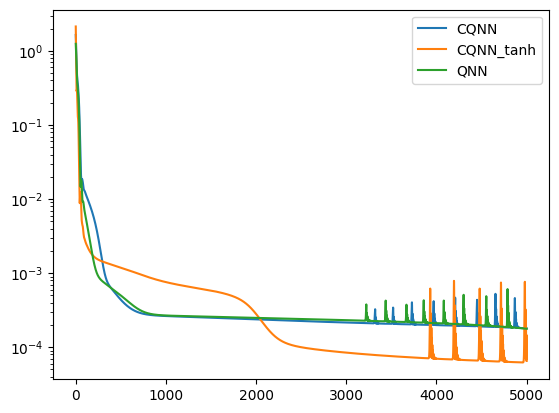

In [21]:
plt.plot(range(1,len(loss_basic["Total"])+1), loss_cqnn["Total"], label="CQNN")
plt.plot(range(1,len(loss_basic["Total"])+1), loss_cqnn_tanh["Total"], label="CQNN_tanh")
plt.plot(range(1,len(loss_basic["Total"])+1), loss_strong["Total"], label="QNN")

plt.yscale("log")

#plt.plot(range(1,len(loss["Total"])+1), loss["boundary_0_loss"], label="S=0")
#plt.plot(range(1,len(loss["Total"])+1), loss["boundary_max_loss"], label="S_max")
#plt.plot(range(1,len(loss["Total"])+1), loss["pde_loss"], label="PDE")
#plt.plot(range(1,len(loss["Total"])+1), loss["terminal_loss"], label="t=tau")

plt.legend()
plt.show()

In [22]:
# 3) MLP clássico (ajuste os nomes dos args: era hidden/blocks)
model = MLP(hidden=4, blocks=5, activation=nn.Tanh(),
            device=device)

opt = BlackScholeOptimizer(data, model,
                           epochs=epochs, lr=lr,
                           device=device)

loss = opt.train(return_loss=True)

NameError: name 'MLP' is not defined

In [ ]:
# =========================================================
# EXEMPLOS DE USO
# =========================================================

if __name__ == "__main__":
    n_qubits = 4
    n_layers = 2

    # -----------------------------------------------------
    # Exemplo 1: usar BasicEntanglerLayers
    # -----------------------------------------------------
    basic_ansatz = make_ansatz("basic")

    model_basic = QuantumNeuralNetwork(
        n_qubits=n_qubits,
        n_layers=n_layers,
        ansatz_fn=basic_ansatz,
        circuit_type="basic",
        device="auto",
    )

    # -----------------------------------------------------
    # Exemplo 2: usar StronglyEntanglingLayers
    # -----------------------------------------------------
    strong_ansatz = make_ansatz("strong")

    model_strong = QuantumNeuralNetwork(
        n_qubits=n_qubits,
        n_layers=n_layers,
        ansatz_fn=strong_ansatz,
        circuit_type="strong",
        device="auto",
    )

    # -----------------------------------------------------
    # Exemplo 3: correlator com basic
    # -----------------------------------------------------
    model_corr = CorrelatorQuantumNeuralNetwork(
        n_qubits=n_qubits,
        n_layers=n_layers,
        k=2,
        n_vertex=6,
        ansatz_fn=basic_ansatz,
        circuit_type="basic",
        device="auto",
    )